# Regression Model 2

This notebook implements regression models for predicting flow_duration. It uses the preprocessing decisions and train/test split from the regression preprocessing stage (same split as Regression Model 1, for a fair comparison).

## Load Data and Split

We load the cleaned dataset and use the saved train/test indices to ensure reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Load cleaned dataset
df = pd.read_csv("../data/RT_IOT2022_cleaned.csv")
print("Dataset shape:", df.shape)

Dataset shape: (117922, 83)


In [2]:
# Load saved split indices
split_data = np.load("regression_split_indices.npz")
train_indices = split_data['train_indices']
test_indices = split_data['test_indices']

print(f"Train indices: {len(train_indices)}")
print(f"Test indices: {len(test_indices)}")

Train indices: 94337
Test indices: 23585


In [3]:
# Apply the same feature selection as preprocessing notebook
target = "flow_duration"

# Columns to drop (same as preprocessing)
drop_cols = []
timing_cols = [col for col in df.columns if 'iat' in col.lower()]
drop_cols.extend(timing_cols)
active_cols = [col for col in df.columns if col.startswith('active.')]
drop_cols.extend(active_cols)
idle_cols = [col for col in df.columns if col.startswith('idle.')]
drop_cols.extend(idle_cols)
rate_cols = ['fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'payload_bytes_per_second']
rate_cols = [col for col in rate_cols if col in df.columns]
drop_cols.extend(rate_cols)
if 'Attack_type' in df.columns:
    drop_cols.append('Attack_type')

df_reg = df.drop(columns=drop_cols)
print(f"Features after selection: {len(df_reg.columns)}")

Features after selection: 53


In [4]:
# Create engineered feature
df_reg['total_packets'] = df_reg['fwd_pkts_tot'] + df_reg['bwd_pkts_tot']
print("Created feature: total_packets")

Created feature: total_packets


In [5]:
# Split using saved indices
X = df_reg.drop(columns=[target])
y = df_reg[target]

X_train = X.loc[train_indices]
X_test = X.loc[test_indices]
y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (94337, 53)
X_test shape: (23585, 53)
y_train shape: (94337,)
y_test shape: (23585,)


In [6]:
# Identify categorical and numerical columns
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features: {cat_cols}")
print(f"Numerical features: {len(num_cols)}")

Categorical features: ['proto', 'service']
Numerical features: 51


## 1. Linear Regression

Linear Regression is the baseline model for this track. It assumes a linear relationship between the network-flow features and flow_duration, fitting a coefficient to each feature. Unlike the tree-based models in Regression Model 1, linear models need scaled numerical features, so the preprocessing pipeline here includes a `StandardScaler` in addition to one-hot encoding.

In [7]:
# Create preprocessing pipeline (categorical encoding + numerical scaling)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

# Create Linear Regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print("Linear Regression pipeline created")

Linear Regression pipeline created


In [8]:
# Train Linear Regression
lr_pipeline.fit(X_train, y_train)
print("Linear Regression training complete")

Linear Regression training complete


In [9]:
# Predict and evaluate
y_pred_lr = lr_pipeline.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"R²: {r2_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")

Linear Regression Results:
R²: -4.3657
RMSE: 135.9027
MAE: 4.6674


In [10]:
# Store results
results = []
results.append({
    'Model': 'Linear Regression',
    'R2': r2_lr,
    'RMSE': rmse_lr,
    'MAE': mae_lr
})

results_df = pd.DataFrame(results)
print(results_df)

               Model        R2        RMSE       MAE
0  Linear Regression -4.365703  135.902724  4.667439


### Linear Regression Coefficients

Extract and display the fitted coefficients. Because numerical features were standardized, the magnitude of each coefficient is a rough indicator of that feature's relative influence on the prediction (larger magnitude → stronger linear effect on flow_duration, holding other features fixed).

In [11]:
# Get feature names after preprocessing
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
print(f"Total features after encoding: {len(feature_names)}")

Total features after encoding: 64


In [12]:
# Get coefficients
coefficients = lr_pipeline.named_steps['regressor'].coef_

# Create DataFrame for coefficients, sorted by absolute magnitude
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', key=np.abs, ascending=False)

# Display top features
print("Top 15 features by coefficient magnitude:")
print(coef_df.head(15))

Top 15 features by coefficient magnitude:
                      feature  coefficient
15          num__fwd_pkts_tot   831.266556
17     num__fwd_data_pkts_tot  -717.345604
16          num__bwd_pkts_tot  -503.742243
20   num__fwd_header_size_tot  -362.133285
18     num__bwd_data_pkts_tot   359.371784
7            cat__service_irc  -346.490311
63         num__total_packets   291.462742
31   num__flow_ACK_flag_count  -217.935959
29    num__fwd_PSH_flag_count   170.223300
23   num__bwd_header_size_tot   159.621743
12           cat__service_ssl   125.775515
6           cat__service_http   114.087034
37  num__fwd_pkts_payload.tot    98.246860
11           cat__service_ssh    97.979841
42  num__bwd_pkts_payload.tot   -82.106641


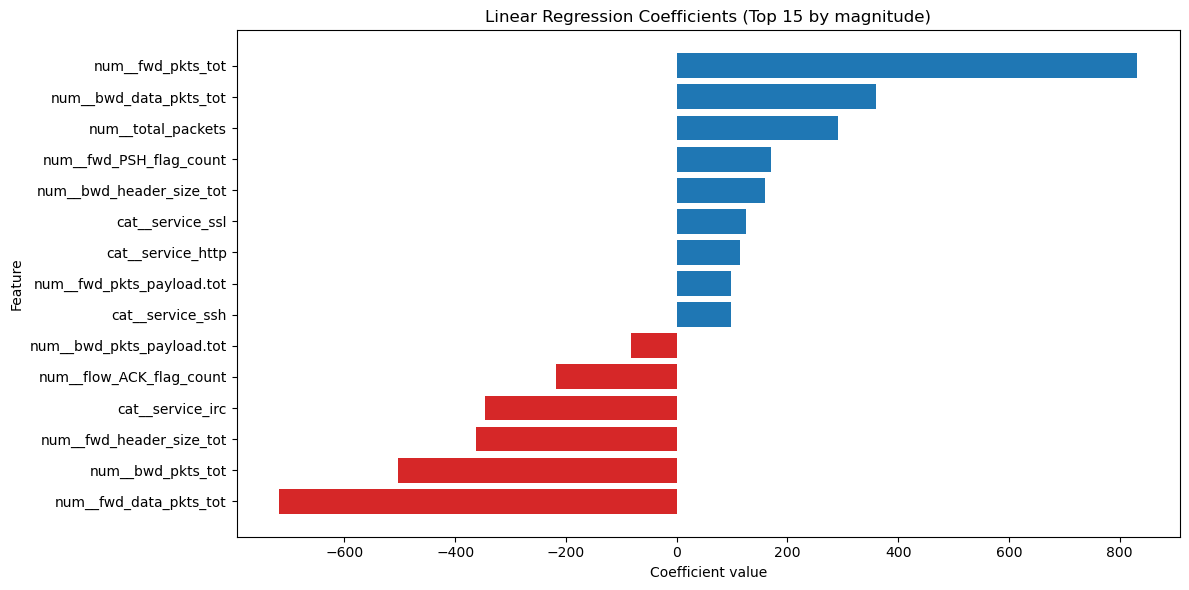

In [13]:
# Plot coefficient magnitudes
plt.figure(figsize=(12, 6))
top_coefs = coef_df.head(15).sort_values('coefficient')
colors = ['tab:red' if c < 0 else 'tab:blue' for c in top_coefs['coefficient']]
plt.barh(top_coefs['feature'], top_coefs['coefficient'], color=colors)
plt.xlabel('Coefficient value')
plt.ylabel('Feature')
plt.title('Linear Regression Coefficients (Top 15 by magnitude)')
plt.tight_layout()
plt.show()

### Interpretation

The R² for plain Linear Regression is negative on the held-out test set, meaning it performs worse than simply predicting the mean flow_duration for every flow. This is expected here for a few reasons:

- **Highly skewed target:** flow_duration has a long right tail (a small number of very long-lived flows), which an unregularized linear model fits poorly since ordinary least squares is sensitive to outliers.
- **Multicollinearity among packet-count features:** `fwd_pkts_tot`, `bwd_pkts_tot`, `fwd_data_pkts_tot`, `bwd_data_pkts_tot`, and the engineered `total_packets` are all highly correlated with each other. This inflates coefficient magnitudes and makes the fitted line unstable on unseen data.
- **No regularization:** Linear Regression has no mechanism to shrink or stabilize these inflated coefficients.

This motivates the regularized linear models (Ridge, ElasticNet) that follow in this track — they are expected to handle the correlated features and skewed target more gracefully than plain OLS. This comparison will be included in the final summary table.